In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Loading the Dataset
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Data Cleaning
threshold = len(df) * 0.5
df = df.dropna(thresh= threshold, axis= 1)

numerical_cols = df.select_dtypes(include= ['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
    
print("Remaining columns count: ", len(df.columns)) 
print("Missing numerical values left: ", df[numerical_cols].isnull().sum().sum())

Remaining columns count:  76
Missing numerical values left:  0


In [3]:
# Feature Selection
import matplotlib.pyplot as plt
import seaborn as sns

selected_columns = ['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'Neighborhood', 'TotalBsmtSF', 'SalePrice']

df_selected = df[selected_columns].copy()
df_final = pd.get_dummies(df_selected, columns= ['Neighborhood'], drop_first= True)

X = df_final.drop(columns= ['SalePrice'])
y = df_final['SalePrice']

In [4]:
# Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Training Complete!")
print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"Average Prediction Error (RMSE): ${rmse:,.2f}")

Model Training Complete!
R2 Score (Accuracy): 0.8257
Average Prediction Error (RMSE): $36,567.38


In [5]:
# Model Evaluation
df_compare = pd.DataFrame({
     'Actual Price': y_test.values,
     'Predicted Price': y_pred.round(4),
     'Difference(Error)': (y_test.values - y_pred).round(4)
})
df_compare.head(15)

,Actual Price,Predicted Price,Difference(Error)
0,154500,147621.2116,6878.7884
1,325000,332159.8719,-7159.8719
2,115000,106190.9769,8809.0231
3,159000,172138.8623,-13138.8623
4,315500,268058.7263,47441.2737
5,75500,67827.2011,7672.7989
6,311500,226819.5948,84680.4052
7,146000,153282.2178,-7282.2178
8,84500,67285.7260,17214.2740
9,135500,130267.2981,5232.7019


Model Training Complete!
R2 Score (Accuracy): 0.8257
Average Prediction Error (RMSE): $36,567.38


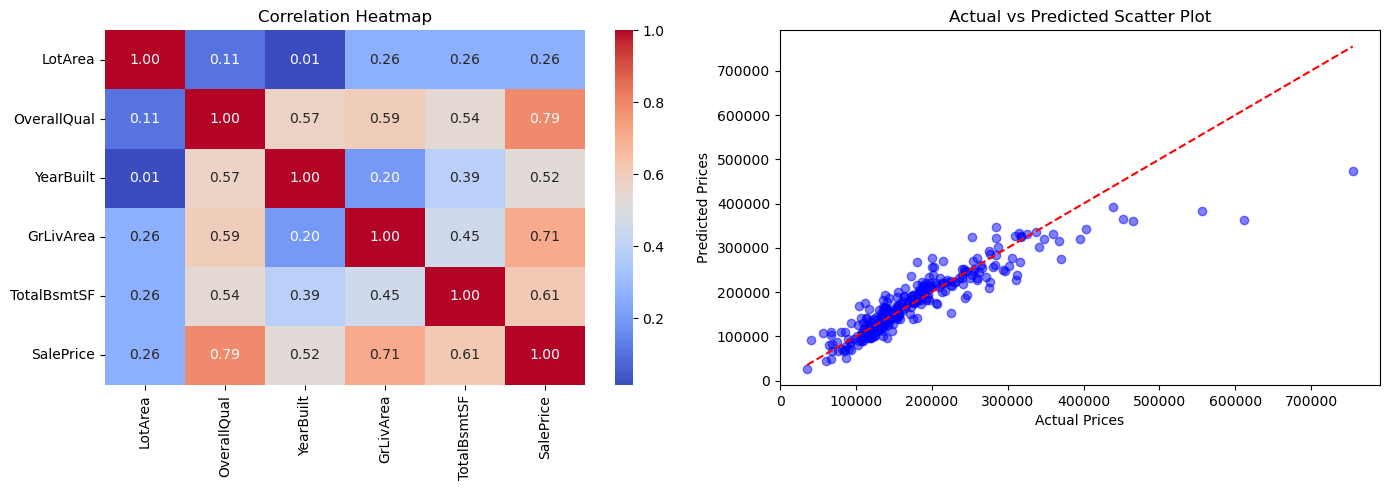

In [6]:
# Visualization
print(f"Model Training Complete!")
print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"Average Prediction Error (RMSE): ${rmse:,.2f}")

plt.figure(figsize= (14, 5))

plt.subplot(1, 2, 1)
numeric_features = ['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'SalePrice']
sns.heatmap(df_selected[numeric_features].corr(), annot= True, cmap= 'coolwarm', fmt= ".2f")
plt.title("Correlation Heatmap")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha= 0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Scatter Plot")

plt.tight_layout()
plt.show()